In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from nltk.tokenize import word_tokenize

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

import transformers
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix
from transformers import RobertaModel, RobertaTokenizer
from transformers import RobertaConfig


import time

import random
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)

In [2]:
FILE_PATH = '../../../cyberbullying_tweets_transformers.csv'
df = pd.read_csv(FILE_PATH)
df = df.dropna(how='any')
df.head()

,text,type,label
0,rape is real..zvasiyana nema jokes about being...,gender,0
1,You never saw any celebrity say anything like ...,gender,0
2,"USER I mean he is gay, but he uses gendered sl...",gender,0
3,retweet USER: USER USER USER feminazi,gender,0
4,Rape is rape. And the fact that I read one pos...,gender,0


In [3]:
df['text_len'] = [len(text.split()) for text in df['text']]
df = df[df["text_len"] > 2]
df = df[df['text_len'] < df['text_len'].quantile(0.995)]
max_len = np.max(df['text_len'])
max_len

61

In [4]:
X = df['text'].values
y = df['label'].values

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed_value)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=seed_value)

In [6]:
print("Train distribution:\n", pd.Series(y_train).value_counts(normalize=True))
print("Test distribution:\n", pd.Series(y_test).value_counts(normalize=True))
print("Valid distribution:\n", pd.Series(y_valid).value_counts(normalize=True))

Train distribution:
 1    0.205249
3    0.203156
4    0.202230
0    0.198970
2    0.190396
Name: proportion, dtype: float64
Test distribution:
 1    0.205307
3    0.203117
4    0.202215
0    0.198995
2    0.190366
Name: proportion, dtype: float64
Valid distribution:
 1    0.205281
3    0.203188
4    0.202222
0    0.199002
2    0.190308
Name: proportion, dtype: float64


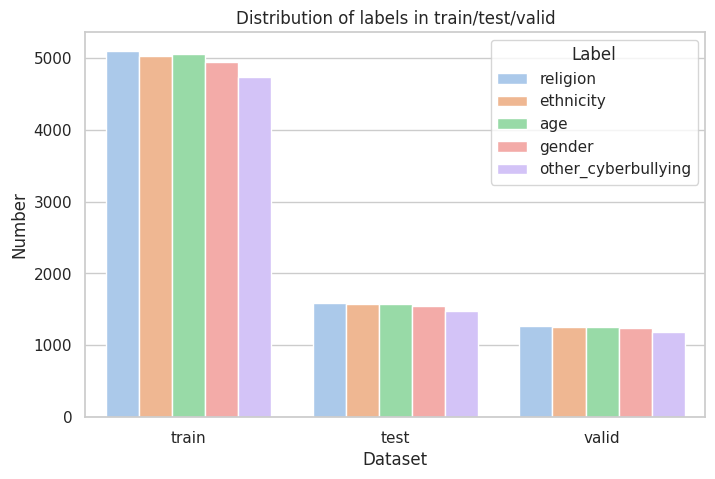

In [7]:
label_to_type = df.drop_duplicates(subset=['label']) \
                       .set_index('label')['type'].to_dict()
df_dist = pd.DataFrame({
    'dataset': ['train'] * len(y_train) + ['test'] * len(y_test) + ['valid'] * len(y_valid),
    'label':  list(y_train) + list(y_test) + list(y_valid)
})
df_dist['type'] = df_dist['label'].map(label_to_type)

sns.set(style='whitegrid')

plt.figure(figsize=(8, 5))
sns.countplot(data=df_dist, x='dataset', hue='type',palette='pastel')
plt.title('Distribution of labels in train/test/valid')
plt.xlabel('Dataset')
plt.ylabel('Number')
plt.legend(title='Label')
plt.show()

In [8]:
ros = RandomOverSampler()

X_train, y_train = ros.fit_resample(
    np.array(X_train).reshape(-1, 1),
    np.array(y_train).ravel()  
)

X_train = X_train.flatten() 
y_train = y_train.flatten()

In [9]:
(unique, counts) = np.unique(y_train, return_counts=True)
np.asarray((unique, counts)).T

array([[   0, 5099],
       [   1, 5099],
       [   2, 5099],
       [   3, 5099],
       [   4, 5099]])

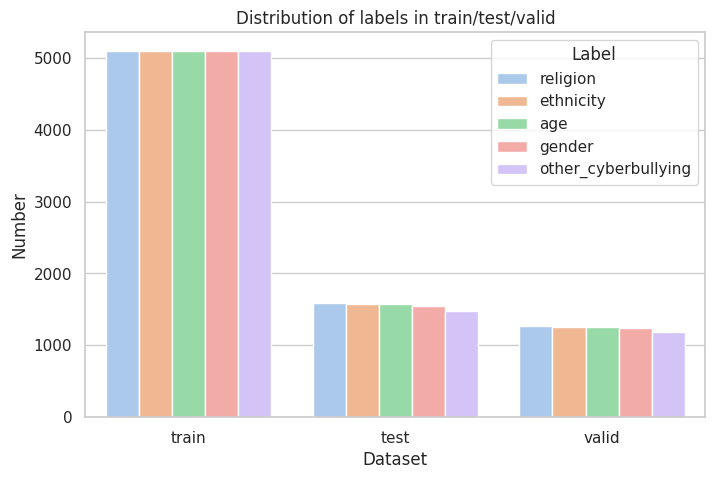

In [10]:
df_dist = pd.DataFrame({
    'dataset': ['train'] * len(y_train) + ['test'] * len(y_test) + ['valid'] * len(y_valid),
    'label':  list(y_train) + list(y_test) + list(y_valid)
})
df_dist['type'] = df_dist['label'].map(label_to_type)

sns.set(style='whitegrid')

plt.figure(figsize=(8, 5))
sns.countplot(data=df_dist, x='dataset', hue='type',palette='pastel')
plt.title('Distribution of labels in train/test/valid')
plt.xlabel('Dataset')
plt.ylabel('Number')
plt.legend(title='Label')
plt.show()

In [11]:
rob_tokenizer = RobertaTokenizer.from_pretrained('roberta-base', truncation=True)

In [12]:
def roberta_tokenizer(data):
    input_ids = []
    attention_masks = []
    for sent in data:
        encoded_sent = rob_tokenizer.encode_plus(
            text=sent,
            add_special_tokens=True,
            max_length=MAX_LEN,
            truncation=True,                
            padding='max_length',           
            return_attention_mask=True
        )
        input_ids.append(encoded_sent.get('input_ids'))
        attention_masks.append(encoded_sent.get('attention_mask'))

    input_ids = torch.tensor(input_ids)
    attention_masks = torch.tensor(attention_masks)

    return input_ids, attention_masks

In [13]:
robert_encoded_tweets = [rob_tokenizer.encode(sent, add_special_tokens=True) for sent in X_train]

max_len = max([len(sent) for sent in robert_encoded_tweets])
print('Max length: ', max_len)

Max length:  199


In [14]:
MAX_LEN = 256

In [15]:
train_inputs, train_masks = roberta_tokenizer(X_train)#(X_train_os)
val_inputs, val_masks = roberta_tokenizer(X_valid)
test_inputs, test_masks = roberta_tokenizer(X_test)

In [16]:
train_labels = torch.from_numpy(y_train)#(y_train_os)
val_labels = torch.from_numpy(y_valid)
test_labels = torch.from_numpy(y_test)

In [17]:
batch_size = 32

In [18]:
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_inputs, val_masks, val_labels)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

test_data = TensorDataset(test_inputs, test_masks, test_labels)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

In [26]:
class Roberta_Classifier(nn.Module):
    def __init__(self,
                 freeze_bert=False,
                 bert_dropout=0.3,
                 classifier_dropout=0.3):
        super(Roberta_Classifier, self).__init__()

        n_input = 768
        n_hidden = 50
        n_output = 5

        config = RobertaConfig.from_pretrained(
            "roberta-base",
            hidden_dropout_prob=bert_dropout,
            attention_probs_dropout_prob=bert_dropout
        )
        self.roberta = RobertaModel.from_pretrained(
            "roberta-base",
            config=config
        )

        self.classifier = nn.Sequential(
            nn.Dropout(classifier_dropout),
            nn.Linear(n_input, n_hidden),
            nn.LeakyReLU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(n_hidden, n_output)
        )

        if freeze_bert:
            for param in self.roberta.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_emb = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_emb)
        return logits

In [27]:
def initialize_roberta_model(epochs=4):
    roberta_classifier = Roberta_Classifier(freeze_bert=False)

    roberta_classifier.to(device)

    optimizer = AdamW(roberta_classifier.parameters(),
                      lr=1e-5,    
                      eps=1e-08,   
                      weight_decay=0.01
                      )

    total_steps = len(train_dataloader) * epochs
    num_warmup_steps = int(0.1 * total_steps)

    scheduler = get_linear_schedule_with_warmup(optimizer,
                                                num_warmup_steps=num_warmup_steps,
                                                num_training_steps=total_steps)
    return roberta_classifier, optimizer, scheduler

In [40]:
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
EPOCHS=4

In [41]:
roberta_classifier, roberta_optimizer, roberta_scheduler = initialize_roberta_model(epochs=EPOCHS)

Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.dense.bias', 'lm_head.layer_norm.bias', 'lm_head.decoder.weight', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [42]:
loss_fn = nn.CrossEntropyLoss()

def train(model,
          train_dataloader,
          optimizer,
          scheduler,
          val_dataloader=None,
          epochs=4,
          evaluation=False):

    train_losses      = []
    train_accuracies  = []
    val_losses        = []
    val_accuracies    = []

    print("Start training...\n")
    for epoch_i in range(epochs):
        print("-"*10)
        print(f"Epoch : {epoch_i+1}")
        print("-"*10)
        print("-"*38)
        print(f"{'BATCH NO.':^9} | {'TRAIN LOSS':^12} | {'ELAPSED (s)':^9}")
        print("-"*38)

        t0_epoch, t0_batch = time.time(), time.time()
        total_loss, batch_loss, batch_counts = 0, 0, 0
        train_acc_total = 0  # initializează totalul acurateței

        model.train()
        for step, batch in enumerate(train_dataloader):
            batch_counts += 1
            b_input_ids, b_attn_mask, b_labels = tuple(t.to(device) for t in batch)

            model.zero_grad()
            logits = model(b_input_ids, b_attn_mask)
            loss = loss_fn(logits, b_labels)

            preds = torch.argmax(logits, dim=1).flatten()
            acc = (preds == b_labels).float().mean().item() * 100
            train_acc_total += acc

            batch_loss += loss.item()
            total_loss += loss.item()

            loss.backward()
            optimizer.step()
            scheduler.step()

            if (step % 100 == 0 and step != 0) or (step == len(train_dataloader)-1):
                time_elapsed = time.time() - t0_batch
                print(f"{step:^9} | {batch_loss/batch_counts:^12.6f} | {time_elapsed:^9.2f}")
                batch_loss, batch_counts = 0, 0
                t0_batch = time.time()

        avg_train_loss = total_loss / len(train_dataloader)
        avg_train_acc = train_acc_total / len(train_dataloader)

        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_acc)

        # ─── EVALUATION ───
        if evaluation and val_dataloader is not None:
            model.eval()
            val_loss_list, val_acc_list = [], []

            with torch.no_grad():
                for batch in val_dataloader:
                    vid, vmask, vlab = tuple(t.to(device) for t in batch)
                    logits = model(vid, vmask)
                    loss = loss_fn(logits, vlab).item()
                    val_loss_list.append(loss)

                    preds = torch.argmax(logits, dim=1).flatten()
                    acc = (preds == vlab).float().mean().item() * 100
                    val_acc_list.append(acc)

            avg_val_loss = np.mean(val_loss_list)
            avg_val_acc  = np.mean(val_acc_list)

            val_losses.append(avg_val_loss)
            val_accuracies.append(avg_val_acc)

            time_elapsed = time.time() - t0_epoch
            print("-"*61)
            print(f"{'AVG TRAIN LOSS':^14} | {'TRAIN ACC (%)':^14} | {'VAL LOSS':^10} | {'VAL ACC (%)':^10} | {'TIME (s)':^9}")
            print("-"*61)
            print(f"{avg_train_loss:^14.6f} | {avg_train_acc:^14.2f} | {avg_val_loss:^10.6f} | {avg_val_acc:^10.2f} | {time_elapsed:^9.2f}")
            print("-"*61 + "\n")

        else:
            time_elapsed = time.time() - t0_epoch
            print(f"Epoch {epoch_i+1} completed in {time_elapsed:.2f}s — avg train loss: {avg_train_loss:.4f}, avg train accuracy: {avg_train_acc:.2f}%\n")

    print("Training complete!\n")

    history = {
        "loss": train_losses,
        "accuracy": train_accuracies,
        "val_loss": val_losses,
        "val_accuracy": val_accuracies
    }

    return history

In [43]:
history = train(roberta_classifier, train_dataloader,roberta_optimizer, roberta_scheduler, val_dataloader, epochs=EPOCHS,evaluation=True)

Start training...

----------
Epoch : 1
----------
--------------------------------------
BATCH NO. |  TRAIN LOSS  | ELAPSED (s)
--------------------------------------
   100    |   1.617528   |   31.86  
   200    |   1.614708   |   31.99  
   300    |   1.521568   |   32.04  
   400    |   0.727197   |   31.98  
   500    |   0.490391   |   32.01  
   600    |   0.409664   |   32.04  
   700    |   0.347424   |   31.99  
   796    |   0.334436   |   30.67  
-------------------------------------------------------------
AVG TRAIN LOSS | TRAIN ACC (%)  |  VAL LOSS  | VAL ACC (%) | TIME (s) 
-------------------------------------------------------------
   0.886539    |     63.93      |  0.306656  |   91.14    |  275.07  
-------------------------------------------------------------

----------
Epoch : 2
----------
--------------------------------------
BATCH NO. |  TRAIN LOSS  | ELAPSED (s)
--------------------------------------
   100    |   0.309358   |   32.13  
   200    |   0.288882

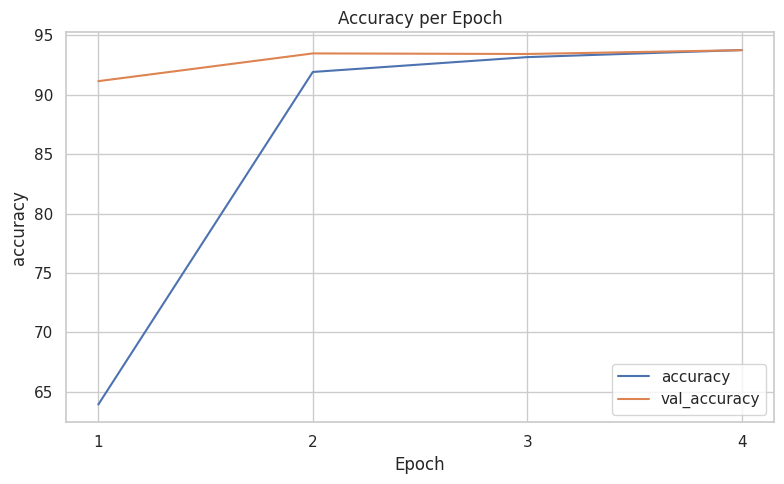

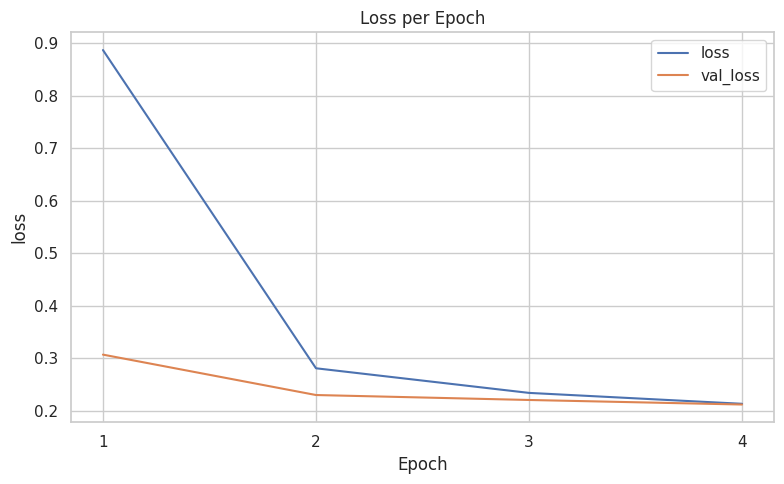

In [44]:
def plot_graphs(history, metric):
    epochs = np.arange(1, len(history[metric]) + 1)

    plt.figure(figsize=(8,5))
    plt.plot(epochs,
             history[metric],
             label=metric)
    plt.plot(epochs,
             history['val_' + metric],
             label='val_' + metric)
    plt.title(f'{metric.capitalize()} per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.xticks(epochs)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [52]:
def predict(model, test_dataloader):
    preds_list = []
    
    model.eval()
    
    for batch in test_dataloader:
        batch_input_ids, batch_attention_mask = tuple(t.to(device) for t in batch)[:2]
       
        with torch.no_grad():
            logit = model(batch_input_ids, batch_attention_mask)
        
        pred = torch.argmax(logit,dim=1).cpu().numpy()
        preds_list.extend(pred)

    return preds_list

In [53]:
roberta_preds = predict(roberta_classifier, test_dataloader)

In [54]:
sentiments = ["religion","age","ethnicity","gender","other_cyberbullying"]

In [55]:
print('Classification Report for ROBERTA :\n', classification_report(y_test, roberta_preds, target_names=sentiments))

Classification Report for ROBERTA :
                      precision    recall  f1-score   support

           religion       0.90      0.89      0.89      1545
                age       0.97      0.98      0.97      1594
          ethnicity       0.87      0.86      0.87      1478
             gender       0.97      0.99      0.98      1577
other_cyberbullying       0.98      0.97      0.97      1570

           accuracy                           0.94      7764
          macro avg       0.94      0.94      0.94      7764
       weighted avg       0.94      0.94      0.94      7764



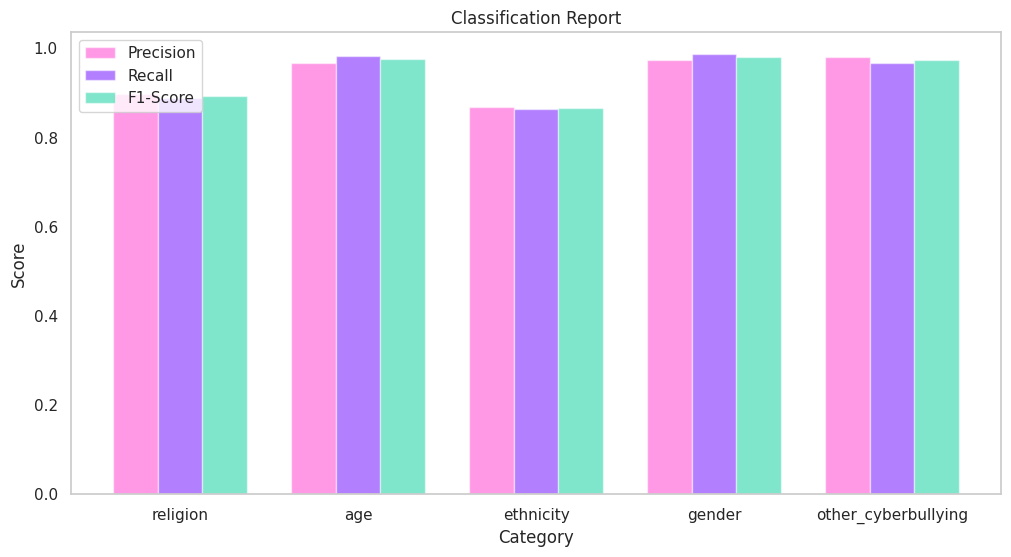

In [56]:
report = classification_report(y_test, roberta_preds, output_dict=True)

fig, ax = plt.subplots(figsize=(12, 6))

categories = list(report.keys())[:-3]  

precision = [report[category]['precision'] for category in categories]
recall = [report[category]['recall'] for category in categories]
f1_score = [report[category]['f1-score'] for category in categories]

pos = list(range(len(categories)))
width = 0.25 

plt.bar(pos, precision, width, alpha=0.5, color='#ff33cc', label='Precision')
plt.bar([p + width for p in pos], recall, width, alpha=0.5, color='#6600ff', label='Recall')
plt.bar([p + width*2 for p in pos], f1_score, width, alpha=0.5, color='#00cc99', label='F1-Score')

plt.xlabel('Category')
plt.ylabel('Score')
plt.title('Classification Report')
plt.xticks([p + width for p in pos], ['religion',
    'age',
    'ethnicity',
    'gender',
    'other_cyberbullying'])


plt.legend(['Precision', 'Recall', 'F1-Score'], loc='upper left')
plt.grid()
plt.show()

In [57]:
def conf_matrix(y, y_pred, title, labels):
    fig, ax =plt.subplots(figsize=(7.5,7.5))
    ax=sns.heatmap(confusion_matrix(y, y_pred), annot=True, cmap="Purples", fmt='g', cbar=False, annot_kws={"size":30})
    plt.title(title, fontsize=25)
    ax.xaxis.set_ticklabels(labels, fontsize=16) 
    ax.yaxis.set_ticklabels(labels, fontsize=14.5)
    ax.set_ylabel('Test', fontsize=25)
    ax.set_xlabel('Predicted', fontsize=25)
    plt.show()

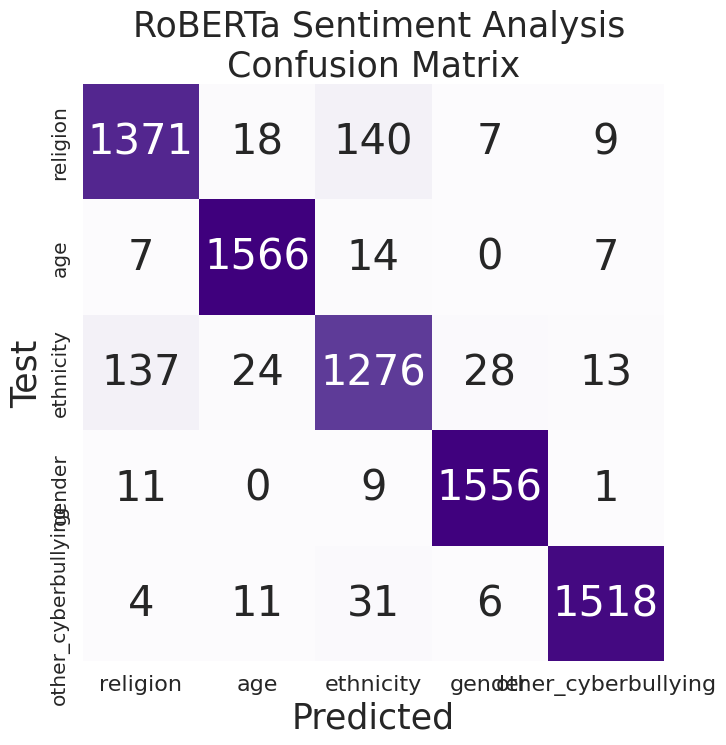

In [58]:
conf_matrix(y_test, roberta_preds,' RoBERTa Sentiment Analysis\nConfusion Matrix', sentiments)

In [59]:
torch.save(roberta_classifier.state_dict(), "roberta_cyberbullying_model.pth")